In [1]:
import string
import pandas as pd
import os
from Util import levelOrder,chunkObjectList,printArr
from enum import Enum
import json
from reflex_database import LoadFileForUsers, LoadEyeGazeForUsers

alphabet = list(string.ascii_uppercase)
class  EyeGazeClusterMetric(Enum):
    Euclidean =1,
    HausdorffDist =2,
           
class  EyeGazeClusterAlgor(Enum):
    KMean =1,
    PAM =2,
    Agglomerative =3,
        


path = "../data/Reflex_data/simple_3joints/otherInfo/"
database = LoadEyeGazeForUsers(path)
maxUser = 16

Openning player0_EyeGazeEvent.csv
Openning player10_EyeGazeEvent.csv
Openning player11_EyeGazeEvent.csv
Openning player12_EyeGazeEvent.csv
Openning player13_EyeGazeEvent.csv
Openning player14_EyeGazeEvent.csv
Openning player15_EyeGazeEvent.csv
Openning player1_EyeGazeEvent.csv
Openning player2_EyeGazeEvent.csv
Openning player3_EyeGazeEvent.csv
Openning player4_EyeGazeEvent.csv
Openning player5_EyeGazeEvent.csv
Openning player6_EyeGazeEvent.csv
Openning player7_EyeGazeEvent.csv
Openning player8_EyeGazeEvent.csv
Openning player9_EyeGazeEvent.csv


In [2]:
clusterSetting = None
with open("./Setting/ClusterSetting.json") as json_file:
    clusterSetting = json.load(json_file)

feature_config = clusterSetting['EyeGaze_Features']


In [3]:
import string
from sgt import SGT
import numpy as np
from itertools import chain
from sklearn.decomposition import PCA

import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from EyegazeCluster import ConstructChunkDurSeq,FilterChunks,AddChunkCode,SelectChunksOfInterest,ConsturctChunkSequence,ConstructChunkDurSeq
from EyegazeCluster import merge_chunks,ConvertSequenceToEmbedding,Run_PCA
from EyegazeCluster import Construct_HausdorffDistanceMatrix,Construct_KMeanCluster,Construct_AgglomerativeClustering,Construct_Dynmasc,Construct_PAM
from EyegazeCluster import GetChunkAndObjFromSequence,AppendFeatures2,AppendFeatures

database  = AddChunkCode(database)
startChunk =int(clusterSetting['startChunk']) 
endChunk = int(clusterSetting['endChunk'])

chunkNames = [ levelOrder[i]for i in range(startChunk,endChunk)] 
printArr(chunkNames, "selected chunk name")

minFixationDur = int(clusterSetting['minFixation']) #10 # min number of frame to be consider as fixation
 
clusterAlgo =  clusterSetting['EyeGaze_Algo']
clusterMetric = clusterSetting['EyeGaze_Metric']
nclusters = int(clusterSetting['NumCluster'])  #3
feature_config = clusterSetting['EyeGaze_Features']
featNameArr = [feature for feature, shouldUse in feature_config.items() if shouldUse and feature != "Fixation"]



df = SelectChunksOfInterest(database, chunkNames)
df = merge_chunks(df)
df = FilterChunks(df, minFixationDur)

if(df['id'].unique().size != database['id'].unique().size):
    s = "[warning]"+"origian database user count " + str(database['id'].unique().size) +"  but filtered database has "+str(df['id'].unique().size)
    print(s)
selectedChunksequence_df, chunk_alphabets = ConsturctChunkSequence(df)

selectedChunksequence_df,nfeatureArr = ConstructChunkDurSeq(df, selectedChunksequence_df,featNameArr)



selected chunk name: [CoinsOnly1,CBSwipeUp1,ObstacleSpec3,ObstacleSpec2,CBLeft2,CoinsOnly2,ObstacleSpec5,]
    id                                           sequence
0    0  [C3, C5, C4, C5, C4, C3, C4, C5, D8, D2, E6, E...
1   10  [D1, D8, D1, D6, D1, D8, D1, D6, E12, E6, E13,...
2   11  [C0, C1, C0, C1, C2, D2, E0, E6, D0, E12, E6, ...
3   12  [C0, C1, C2, C1, D7, D2, D7, E12, F10, E6, F10...
4   13                  [C4, C5, D2, D7, E6, G11, H1, H2]
5   14  [C5, C4, C5, D8, D7, D0, E6, E12, E6, F10, F9,...
6   15  [C0, C1, D7, D2, D7, D2, E12, F6, E6, F10, F7,...
7    1  [C0, D1, E0, F10, G0, G1, G6, G0, G6, G1, G7, ...
8    2  [C0, C1, C0, C1, C2, D7, D2, E0, D1, E12, E1, ...
9    3  [C0, C1, C0, C1, C2, D7, D2, D7, D2, D7, E0, D...
10   4  [C4, C3, D1, D6, F9, F6, F9, F6, F9, F7, G11, ...
11   5  [C1, C2, C1, C2, D0, D7, D2, E6, E0, E6, F9, F...
12   6  [C1, C3, C4, C3, C4, C5, D2, D7, D2, D1, D6, E...
13   7  [C0, C1, C2, C1, C0, C1, C2, D7, D2, D1, E6, D...
14   8  [C0, C1, C0, C1

In [4]:
import itertools


sgtembedding_df = None
hasFixation = any(shouldUse and feature == "Fixation" for feature, shouldUse in feature_config.items()) 
if(hasFixation):
    temp_df = selectedChunksequence_df.copy(deep= True)
    #construct segmentation embedding
    sgtembedding_df = ConvertSequenceToEmbedding(temp_df, chunk_alphabets)
    if(len(featNameArr) != 0):
        sgtembedding_df = AppendFeatures(sgtembedding_df, selectedChunksequence_df,nfeatureArr)
    print(f"embedding dataset shape {selectedChunksequence_df.head()}" )

else:
    sgtembedding_df = AppendFeatures2(selectedChunksequence_df,nfeatureArr)

print(f"[ConvertSequenceToEmbedding] output sgtembedding_df\n {sgtembedding_df.columns}" )
#print(f"{sgtembedding_df.head()}")

Convert sequence into Embedding; return df num_sampels X embedding_dimension = (16, 1157)
[AppendFeatures]input dataset shape (16, 7) output  (16, 1159)
embedding dataset shape    id                                           duration  SumDur     StdDur  \
0   0  [10, 1, 1, 16, 30, 22, 18, 23, 17, 25, 11, 3, ...   444.0  13.128121   
1  10  [8, 17, 2, 1, 6, 21, 8, 25, 4, 2, 12, 15, 31, ...   198.0   8.707364   
2  11  [23, 2, 29, 48, 4, 53, 2, 2, 8, 6, 15, 26, 30,...   455.0  24.580486   
3  12  [4, 36, 13, 13, 8, 16, 24, 58, 0, 13, 22, 2, 5...   353.0  11.978730   
4  13                     [25, 59, 15, 0, 55, 36, 41, 8]   239.0  20.176952   

    nSumDur   nStdDur                                           sequence  
0 -0.160141 -1.028982  [C3, C5, C4, C5, C4, C3, C4, C5, D8, D2, E6, E...  
1 -1.845479 -1.799924  [D1, D8, D1, D6, D1, D8, D1, D6, E12, E6, E13,...  
2 -0.084781  0.968212  [C0, C1, C0, C1, C2, D2, E0, E6, D0, E12, E6, ...  
3 -0.783579 -1.229426  [C0, C1, C2, C1, D7, D2, 

In [5]:


def Run_PCA(input_df,num_comp = 5):
    input_df.columns = input_df.columns.astype(str)
    #[Warning] need to drop all other column(e.g., id, duration); left with chunk seq code only 
    sgtembedding_df = input_df.drop(columns = 'id')
    
    pca = PCA(n_components=num_comp)
   
    
    #sum of PCA descript how much of total variance is retained after transformation
    X=pca.fit_transform(sgtembedding_df)#X = num_samples X num_comp
    #Check out how much original variance is captured by each principla componnent
    print(f"Run PCA; df numSample {len(X) } X {num_comp} components; \nsum of PCA {np.sum(pca.explained_variance_ratio_)}" )
    pca_df = pd.DataFrame(data=X, columns=['x'+ str(i) for i in range(num_comp)])
    
    #print(sgtembedding_df.head())
    pca_df['id'] = input_df['id'] #adding id col back
    print("After run PCA")
    print(pca_df.head())
    return pca_df,X

num_comp = 3
if(sgtembedding_df.shape[1] >3):
    pca_df,X = Run_PCA(sgtembedding_df, num_comp)
    
else:
    pca_df = sgtembedding_df
    X = sgtembedding_df.copy().drop(columns = 'id')
    X = X.to_numpy()
    print(X)


Run PCA; df numSample 16 X 3 components; 
sum of PCA 0.5156910164409212
After run PCA
         x0        x1        x2    id
0  0.485032 -1.502691  1.267792   0.0
1  2.546361 -1.893578  0.152824  10.0
2  0.140822  1.341072 -1.028793  11.0
3  0.278916 -1.942962 -0.845284  12.0
4  2.330834  0.179539 -0.008229  13.0


In [6]:
from scipy.spatial.distance import directed_hausdorff,cdist
from sklearn.metrics import silhouette_score

def Construct_HausdorffDistanceMatrix2(X1,X2):
    
        # Calculate pairwise distances between all points
    distances = cdist(X1, X2, metric = 'euclidean')
        
    
    
    min_distances_to_array2 = np.min(distances, axis=1)
    
    # For each point in array2, find its minimum distance to any point in array1
    min_distances_to_array1 = np.min(distances, axis=0)
    
    # The Hausdorff distance between each pair of points is the maximum of their minimum distances
    hausdorff_matrix = np.maximum(min_distances_to_array2[:, None], min_distances_to_array1[None, :])
   
    
    
    return hausdorff_matrix 

def Construct_HausdorffDistanceMatrix(X):
    def directed_hausdorff2(u, v, metric1 = 'euclidean'):
        """
        Calculate the directed Hausdorff distance from array1 to array2.
        
        Parameters:
        array1: numpy array of shape (n, 5) - first set of 5D coordinates
        array2: numpy array of shape (m, 5) - second set of 5D coordinates
        
        Returns:
        float: directed Hausdorff distance from array1 to array2
        """
        print("[directed_hausdorff_distance] u=" , u)
        print("[directed_hausdorff_distance] v=" , v)
        # Calculate pairwise distances between all points
        distances = cdist(u, v, metric = 'euclidean')
        
        # For each point in array1, find its minimum distance to any point in array2
        min_distances = np.min(distances, axis=1)
        
        # The directed Hausdorff distance is the maximum of these minimum distances
        dh = np.max(min_distances)
        
        return dh

    def directed_hausdorff1(u, v):
        #u, v must be size 1 X n 
        #print("[directed_hausdorff_distance] directed_hausdorff=" , directed_hausdorff(u, v))
        return max(directed_hausdorff(u, v)[0], directed_hausdorff(v, u)[0])

    distM = np.zeros((len(X),len(X)))
    for i, u in enumerate(X):
        for j, v in list(enumerate(X))[i:]: #i = 0 ->elem (0,0)..(n,n); i =1 -> elem (1,1)..n

            distM[i,j] = directed_hausdorff1(u.reshape(1,-1),v.reshape(1,-1))         
            distM[j,i] = distM[i,j]
    #print(f"construct distance matrix size  {len(distM)} X{len(distM[0])}")
    return distM 


In [7]:
from sklearn.metrics.pairwise import euclidean_distances
distM = None

if(clusterMetric == EyeGazeClusterMetric.Euclidean.name):
    distM = euclidean_distances(X)
    print("use Euclidean dist matrix")
else:
    distM = Construct_HausdorffDistanceMatrix(X)

labels =  None

if(clusterAlgo ==  EyeGazeClusterAlgor.Agglomerative.name):
#
    labels,_ = Construct_AgglomerativeClustering(distM, nclusters)
elif (clusterAlgo ==  EyeGazeClusterAlgor.KMean.name):
    labels,_ = Construct_KMeanCluster(X, nclusters)
else:
    labels,_ = Construct_PAM(X, distM, nclusters)


pca_df['GroupID'] = labels

for index, row in selectedChunksequence_df.iterrows():
    uid =  row['id'] 
   
    selectrow =  pca_df[(pca_df['id'] == uid)]
    if not selectrow.empty:
        selectedChunksequence_df.at[index, 'GroupID'] = selectrow.iloc[0]['GroupID']
    else:
        print("Select row is empty")


pca_df

use Euclidean dist matrix


c:\Users\z5308\.conda\envs\vrtest\lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
c:\Users\z5308\.conda\envs\vrtest\lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,x0,x1,x2,id,GroupID
0,0.485032,-1.502691,1.267792,0.0,0
1,2.546361,-1.893578,0.152824,10.0,0
2,0.140822,1.341072,-1.028793,11.0,2
3,0.278916,-1.942962,-0.845284,12.0,0
4,2.330834,0.179539,-0.008229,13.0,2
5,1.980456,-0.342652,0.557789,14.0,0
6,1.537217,0.057260,-0.516666,15.0,2
7,0.342100,1.619512,-0.334587,1.0,2
8,-1.206066,0.122461,-0.895494,2.0,1
9,-2.087895,0.168391,-0.820642,3.0,1


In [8]:
import re
from typing import List, Tuple


selectedChunksequence_df['chunks'] = [[] for _ in range(len(selectedChunksequence_df))]
selectedChunksequence_df['chunkObjs'] = [[] for _ in range(len(selectedChunksequence_df))]
for index, row in selectedChunksequence_df.iterrows():
        flattened_sequence = row['sequence']
        chunks, chunkObjs = GetChunkAndObjFromSequence( flattened_sequence)
        #print(f"flatten {flattened_sequence}  chunks {chunks}   \n ")
        selectedChunksequence_df.at[index,'chunks'] = chunks
        selectedChunksequence_df.at[index,'chunkObjs'] = chunkObjs



In [9]:
# for gi in range(-1, nclusters):
#     t = selectedChunksequence_df[(selectedChunksequence_df['GroupID'] == gi)]
#     selectCol = ['id','sequence']+ nfeatureArr
    #print(f"group = {gi};\n {t[selectCol]}  ") 


# print(dataset[['id', 'GroupID']])

featureArr = [feature for feature in featNameArr] 
selectCol = ['id', 'GroupID'] + featureArr+['chunks', 'chunkObjs']
df2 = selectedChunksequence_df[selectCol]
df2 = df2.rename(columns={'id': 'userID'})
for i in range(maxUser):
    # if this user does not has a group
    if(df2[df2['userID'] == i].empty) :
        df2.loc[df2.shape[0]] = {'userID': i, 'GroupID' : -1}

# df2['GroupID'] = df2['GroupID'].fillna(-1)
df2['dummy'] = 0
print(df2)
# # Save the updated CSV file
df2.to_csv('C:/Users/z5308/Desktop/VRTestingProject/data/Reflex_data/simple_3joints/FinalEyeGazeInfo.csv', index=False)



   userID  GroupID  SumDur     StdDur  \
0       0      0.0   444.0  13.128121   
1      10      0.0   198.0   8.707364   
2      11      2.0   455.0  24.580486   
3      12      0.0   353.0  11.978730   
4      13      2.0   239.0  20.176952   
5      14      0.0   296.0  17.682194   
6      15      2.0   346.0  20.556927   
7       1      2.0   514.0  25.598090   
8       2      1.0   560.0  17.012513   
9       3      1.0   704.0  17.347622   
10      4      2.0   400.0  32.342878   
11      5      2.0   589.0  22.900108   
12      6      1.0   575.0  19.154215   
13      7      1.0   640.0  18.750868   
14      8      1.0   536.0  12.260783   
15      9      1.0   629.0  22.278764   

                                             duration  \
0   [10, 1, 1, 16, 30, 22, 18, 23, 17, 25, 11, 3, ...   
1   [8, 17, 2, 1, 6, 21, 8, 25, 4, 2, 12, 15, 31, ...   
2   [23, 2, 29, 48, 4, 53, 2, 2, 8, 6, 15, 26, 30,...   
3   [4, 36, 13, 13, 8, 16, 24, 58, 0, 13, 22, 2, 5...   
4                

array([0, 0, 2, 0, 2, 0, 2, 2, 1, 1, 2, 2, 1, 1, 1, 1])

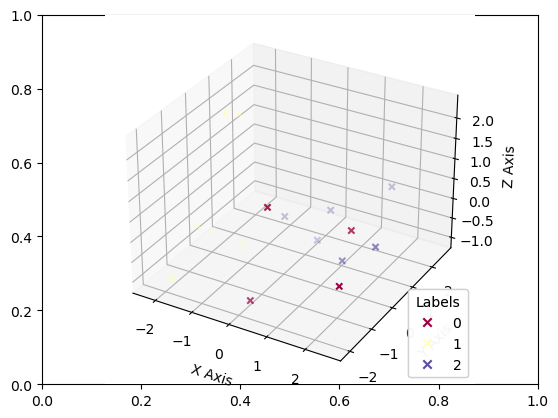

In [10]:
fig, ax = plt.subplots()
#colmap = {1: 'r', 2: 'g', 3: 'b',4:'k',5:'y'}
#colors = list(map(lambda x: colmap[x+1], labels))
#colors = 
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(pca_df['x0'], pca_df['x1'], pca_df['x2'], c=labels, cmap='Spectral',  marker='x')
ax.set_xlabel('X Axis')
ax.set_ylabel('Y Axis')
ax.set_zlabel('Z Axis')


legend1 = ax.legend(*scatter.legend_elements(),
                    loc="lower right", title="Labels")
# kw = dict(prop="sizes", num=5, color=scatter.cmap(0.7), fmt="{x:.0f}",
#           func=lambda s: s)

# legend1 = ax.legend(*scatter.legend_elements(**kw),
#                     loc="upper right", title="label")
ax.add_artist(legend1)


#print(sequence_df.head())
#plt.scatter(pca_df['x1'], pca_df['x2'], pca_df['x3'], color=co
# lors, alpha=0.5, edgecolor=colors)
#plt.show()
labels

In [11]:


#df1 = pd.read_csv('C:/Users/z5308/Desktop/VRTestingProject/data/Reflex_data/simple_3joints/DiscreteInfo.csv')
#df2 = selectedChunksequence_df[['userID', 'GroupID']]

#final_df = pd.merge(df1, df2, on='userID', how='inner', validate= 'one_to_one')

#print(final_df)
# Save the updated CSV file
#final_df.to_csv('C:/Users/z5308/Desktop/VRTestingProject/data/Reflex_data/simple_3joints/FinalInfo.csv', index=False)

